d:\git\PhDProjects\LungCancerGrading\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
patients: 100%|██████████| 211/211 [35:18<00:00, 10.04s/it]


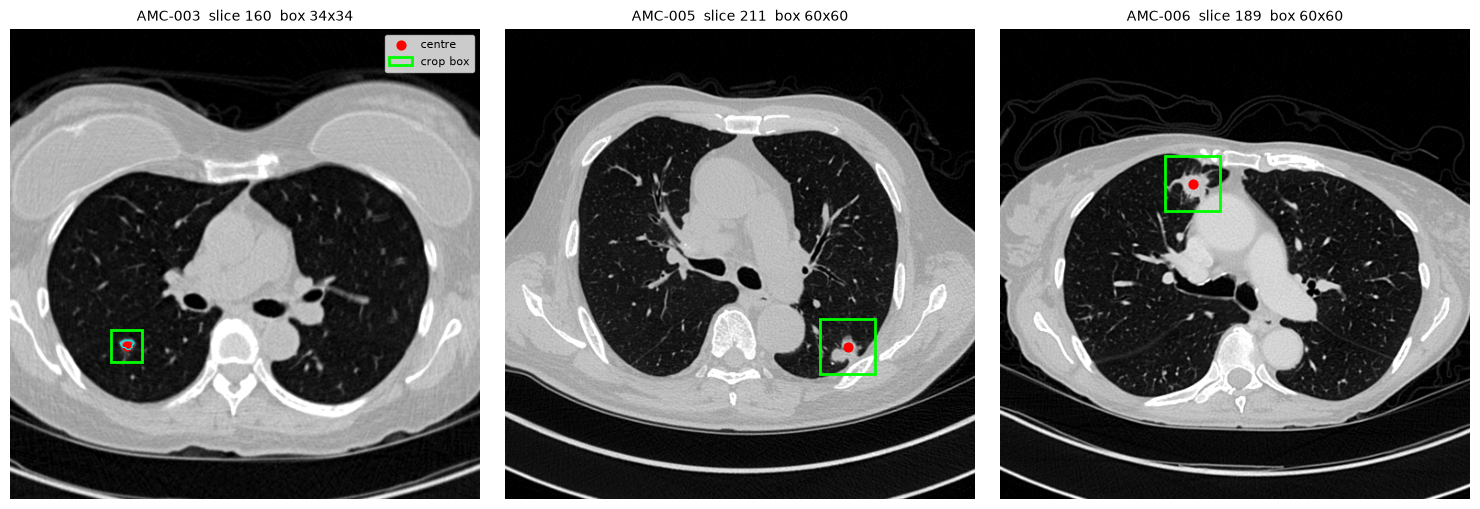


Exact SOP matches: 185 | frame fallbacks: 6 | unresolved: 0


In [1]:
# %% [markdown]
# # AIM Global Resolution + DYNAMIC tumour box (lung-gated region-grow sizing)
# Finds the markup's series anywhere in the patient folder, then sizes the crop box to the
# actual tumour by region-growing from the markup centre (no more fixed 72x72). The grow is
# confined to the lung field (+rim), so peripheral tumours no longer leak into the chest wall.

# %%
import os, glob, math
import xml.etree.ElementTree as ET
import numpy as np, pandas as pd
import pydicom, SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import ndimage
from skimage.morphology import disk as skdisk
from pathlib import Path
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x

DATA_ROOT = Path("data/nsclc_radiogenomics")
AIM_DIR   = Path("data/AIM_files_updated-11-10-2020/AIM_files_updated-11-10-2020")
CLINICAL_CSV = Path("data/NSCLCR01Radiogenomic_DATA_LABELS_2018-05-22_1500-shifted.csv")

def _local(t): return t.rsplit('}', 1)[-1]

def parse_aim_markup(xml_path):
    out = []
    try: root = ET.parse(xml_path).getroot()
    except Exception: return out
    for me in root.iter():
        if _local(me.tag) != "MarkupEntity": continue
        sop=None; frame=None; pts=[]
        for el in me.iter():
            lt=_local(el.tag)
            if lt=="imageReferenceUid": sop=el.get("root")
            elif lt=="referencedFrameNumber": frame=el.get("value")
            elif lt=="TwoDimensionSpatialCoordinate":
                x=y=None
                for c in el:
                    if _local(c.tag)=="x": x=float(c.get("value"))
                    if _local(c.tag)=="y": y=float(c.get("value"))
                if x is not None and y is not None: pts.append((x,y))
        if pts: out.append({"sop":sop, "frame":int(frame) if frame else None, "xy":pts})
    return out

def find_series_for_sops(pdir, target_sops):
    found = {}
    for root, _, files in os.walk(pdir):
        if len(found) == len(target_sops): break
        dcms = [f for f in files if f.lower().endswith(".dcm")]
        if not dcms: continue
        try:
            t = pydicom.dcmread(os.path.join(root, dcms[0]), stop_before_pixels=True, force=True)
            if str(getattr(t, "Modality", "")).upper() != "CT": continue
        except Exception: continue
        for dcm in dcms:
            try:
                ds = pydicom.dcmread(os.path.join(root, dcm), stop_before_pixels=True, force=True)
                uid = str(getattr(ds, 'SOPInstanceUID', ''))
                if uid in target_sops: found[uid] = root
            except Exception: pass
    return found

def _lung_gate_2d(sl_hu, body_thresh=-500, air_thresh=-400, margin=20):
    """Lung field (aerated lung) dilated by `margin` px. Confining the region-grow
    to this gate keeps it from leaking into the chest wall / mediastinum, while the
    rim still admits juxtapleural tumours bulging onto the pleura."""
    bdy = ndimage.binary_fill_holes(sl_hu > body_thresh)            # patient body, holes filled
    lbl, n = ndimage.label(bdy)
    if n == 0: return np.zeros(sl_hu.shape, bool)
    bdy = lbl == (np.argmax(ndimage.sum(np.ones_like(lbl), lbl, range(1, n+1))) + 1)
    air = ndimage.binary_opening((sl_hu < air_thresh) & bdy, structure=skdisk(2))  # air inside body = lungs
    lbl, n = ndimage.label(air)
    if n == 0: return np.zeros(sl_hu.shape, bool)
    sizes = ndimage.sum(np.ones_like(lbl), lbl, range(1, n+1))
    keep = np.where(sizes >= 64)[0] + 1                             # drop bowel-gas / airway specks
    lung = np.isin(lbl, keep) if keep.size else (lbl == np.argmax(sizes) + 1)
    return ndimage.binary_dilation(lung, structure=skdisk(margin))

def estimate_tumor_bbox(sl_hu, cx, cy, r_max=55, hu_thresh=-400, min_half=12, pad=10,
                        fallback_half=30, lung_margin=20, lung_gate=None, return_mask=False):
    """Region-grow a soft-tissue blob from (cx,cy) and return a square half-size hugging
    the tumour. Lung-gated: peripheral tumours no longer leak into the chest wall.
    Pass a precomputed `lung_gate` if calling many times on the same slice."""
    H, W = sl_hu.shape
    cyi, cxi = int(round(cy)), int(round(cx))
    y0, y1 = max(0, cyi-r_max), min(H, cyi+r_max+1)
    x0, x1 = max(0, cxi-r_max), min(W, cxi+r_max+1)
    win = sl_hu[y0:y1, x0:x1]; ly, lx = cyi-y0, cxi-x0

    def _ret(half, comp=None):
        if not return_mask: return half
        full = np.zeros(sl_hu.shape, bool)
        if comp is not None: full[y0:y1, x0:x1] = comp
        return half, full

    # --- lung gate: seed must sit inside lung(+rim), else we can't size it reliably ---
    if lung_gate is None:
        lung_gate = _lung_gate_2d(sl_hu, margin=lung_margin)
    if lung_gate is not None and lung_gate.any():
        gw = lung_gate[y0:y1, x0:x1]
        if not gw[ly, lx]:                                          # broad pleural / mediastinal mass
            return _ret(max(min_half, fallback_half))               #   -> safe fixed box, no leak
    else:
        gw = None                                                   # lung detection failed -> guards only

    # soft-tissue candidate inside a bounded disk, confined to the lung gate
    m = win > hu_thresh
    yy, xx = np.ogrid[:win.shape[0], :win.shape[1]]
    disk_win = (yy-ly)**2 + (xx-lx)**2 <= r_max**2
    m &= disk_win
    if gw is not None: m &= gw
    m = ndimage.binary_opening(m, structure=skdisk(2))             # snap thin bridges to chest wall

    comp = None
    if not m[ly, lx]:
        md = ndimage.binary_dilation(m, structure=skdisk(2))
        if md[ly, lx]: m = md
    if m[ly, lx]:
        lbl, _ = ndimage.label(m)
        comp = lbl == lbl[ly, lx]
        ys, xs = np.where(comp)
        h = ys.max()-ys.min()+1; w = xs.max()-xs.min()+1
        fill   = comp.sum() / float(h*w)                           # compactness
        aspect = max(h, w) / float(max(1, min(h, w)))              # elongation
        raw_half = int(np.ceil(max(h, w)/2)) + pad
        # leak guards: too big, too sparse, wall-hugging sliver, or maxed the window
        if (comp.sum() > 0.55*disk_win.sum()) or fill < 0.35 or aspect > 3.0 or raw_half >= r_max:
            comp = None
    if comp is None or comp.sum() < 9:
        return _ret(max(min_half, fallback_half))                  # robust fallback

    ys, xs = np.where(comp)
    half = int(np.ceil(max(ys.max()-ys.min(), xs.max()-xs.min())/2)) + pad
    half = int(np.clip(half, min_half, r_max-1))                   # r_max-1: a true max == leak signal
    return _ret(half, comp)

clin = pd.read_csv(CLINICAL_CSV)
clin["Case ID"] = clin["Case ID"].astype(str).str.strip()
all_aim = glob.glob(os.path.join(str(AIM_DIR), "*.xml"))

success = fallback = unresolved = 0
fig, axes = plt.subplots(1, 3, figsize=(15, 5)); plot_idx = 0

for cid in tqdm(clin["Case ID"], desc="patients"):
    af = [f for f in all_aim if cid in os.path.basename(f)]
    if not af: continue
    markups = parse_aim_markup(af[0])
    if not markups: continue
    pdir = DATA_ROOT/cid
    if not pdir.exists(): continue
    target_sops = {mk["sop"] for mk in markups if mk["sop"]}
    sop_dir = find_series_for_sops(pdir, target_sops)
    for mk in markups:
        sop, frame, pts = mk["sop"], mk["frame"], mk["xy"]
        if sop in sop_dir:
            success += 1
            if plot_idx < 3:
                r = sitk.ImageSeriesReader(); files = r.GetGDCMSeriesFileNames(sop_dir[sop])
                z_idx, cols, rows = 0, 512, 512
                for z, fp in enumerate(files):
                    ds = pydicom.dcmread(fp, stop_before_pixels=True, force=True)
                    if str(getattr(ds, 'SOPInstanceUID', '')) == sop:
                        z_idx = z; cols = getattr(ds,'Columns',512); rows = getattr(ds,'Rows',512); break
                r.SetFileNames(files); arr = sitk.GetArrayFromImage(r.Execute())
                _, cur_Y, cur_X = arr.shape
                sx, sy = cur_X/float(cols), cur_Y/float(rows)
                cx, cy = pts[0][0]*sx, pts[0][1]*sy
                half, mask = estimate_tumor_bbox(arr[z_idx], cx, cy, return_mask=True)   # <-- lung-gated dynamic
                ax = axes[plot_idx]
                ax.imshow(arr[z_idx], cmap="gray", vmin=-1000, vmax=400)
                if mask.any(): ax.contour(mask, colors="cyan", linewidths=0.8)
                ax.scatter([cx], [cy], color='red', s=40, label="centre")
                ax.add_patch(patches.Rectangle((cx-half, cy-half), 2*half, 2*half,
                             linewidth=2, edgecolor='lime', facecolor='none', label="crop box"))
                ax.set_title(f"{cid}  slice {z_idx}  box {2*half}x{2*half}", fontsize=10)
                ax.axis('off')
                if plot_idx == 0: ax.legend(loc="upper right", fontsize=8)
                plot_idx += 1
        elif frame is not None: fallback += 1
        else: unresolved += 1

plt.tight_layout(); plt.show()
print(f"\nExact SOP matches: {success} | frame fallbacks: {fallback} | unresolved: {unresolved}")